In [1]:
import numpy as np
import torch 
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev
from scipy import interpolate

In [2]:
#load in test.csv and test_pv_xrd.pt
#they are in /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only
test_df = pd.read_csv('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/df4.csv')
test_xrd = torch.load('/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd_dict_3.pt')

In [3]:
#select only [:8500] of the values in test_xrd
for key in test_xrd.keys():
    test_xrd[key] = test_xrd[key][:,:8500]

In [4]:
#save the test_xrd dict
torch.save(test_xrd, '/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd_dict_3.pt')

In [5]:
import matplotlib.pyplot as plt
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.core import Structure

def plot_xrd_pattern_from_string(index, plot = False):

    cif_string = test_df['cif'][index]
    xrd_from_test_xrd = test_xrd[test_df['material_id'][index]].numpy()

    # Load the structure from the CIF string
    structure = Structure.from_str(cif_string, fmt="cif")
    # Initialize the XRD calculator with Cu Kα radiation
    xrd_calculator = XRDCalculator(wavelength="CuKa")

    # Get the XRD pattern
    pattern = xrd_calculator.get_pattern(structure)

    myrange = np.arange(5, 90, 0.01)

    #sum the peaks in the bins defined by the range (this adds to the )
    summed_peaks = np.zeros(len(myrange))
    for i in range(len(pattern.x)):
        for j in range(len(myrange)-1):
            if pattern.x[i] > myrange[j] and pattern.x[i] < myrange[j+1]:
                summed_peaks[j] += pattern.y[i]
    summed_peaks = summed_peaks / np.max(summed_peaks)

    #for the peaks that are non-zero in summed-peaks, find the difference in intensity compared to the test_xrd
    residuals = np.zeros(len(summed_peaks))
    for i in range(len(summed_peaks)):
        if summed_peaks[i] > 0.2:
            #compare to the max within 10 bins of the peak
            window = 10
            if window > 0:
                residuals[i] = np.max(xrd_from_test_xrd[0][i-window:i+window]) / summed_peaks[i]
            else:
                residuals[i] = summed_peaks[i] - xrd_from_test_xrd[0][i]

    non_zero_residuals = residuals[residuals != 0]
    if plot == True:
        # Plot the pattern
        plt.figure(figsize=(10, 6))
        # plt.vlines(pattern.x, 0, pattern.y, colors='b')
        plt.vlines(myrange, 0, summed_peaks, colors='b')
        plt.plot(myrange, xrd_from_test_xrd[0], 'r', alpha = 0.5)
        plt.xlabel('2θ')
        plt.ylabel('Intensity')
        plt.title('X-ray Diffraction Pattern')
        plt.xlim(30,40)
        plt.show()

        #plot the residuals
        plt.figure(figsize=(10, 6))
        plt.plot(myrange, residuals)
        plt.xlabel('2θ')
        plt.ylabel('Intensity')
        plt.title('Residuals')
        plt.xlim(30,40)
        plt.show()
        
        # #get non-zero residuals
        # plt.figure(figsize=(5, 3))
        # plt.hist(non_zero_residuals, bins = 10)
        # plt.xlabel('Residuals')
        # plt.ylabel('Counts')
        # plt.title('Residuals')
        # plt.show()
    return residuals, non_zero_residuals


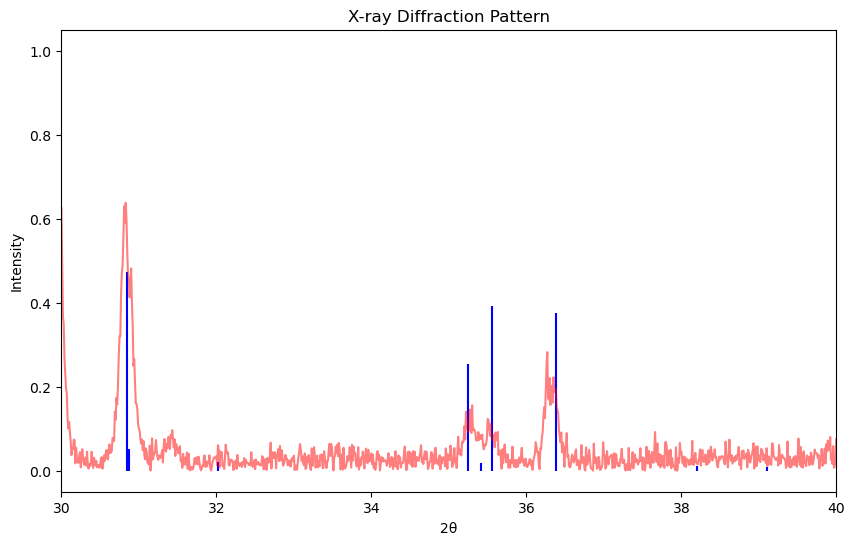

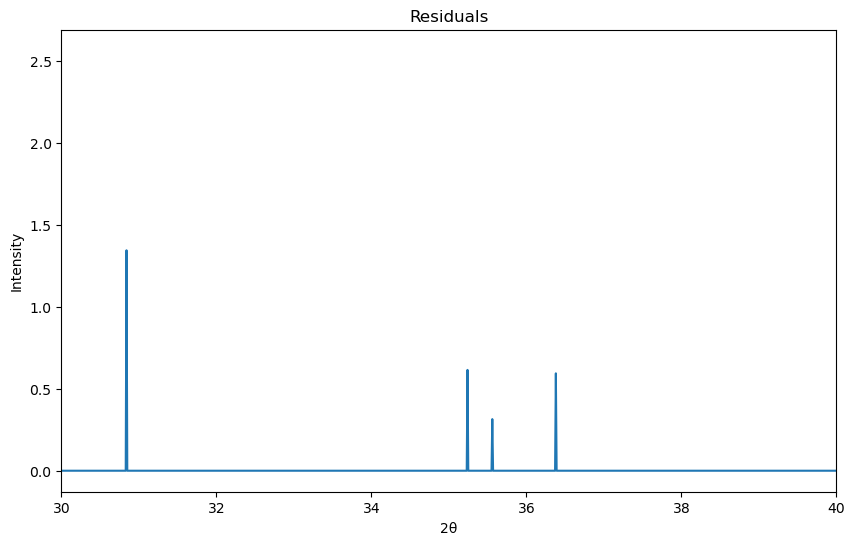

In [9]:
index = 1
residuals, non_zero_residuals = plot_xrd_pattern_from_string(index, plot = True)

In [237]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import curve_fit

def find_peaks_and_fwhm(two_theta, intensity, num_peaks=3):
    peaks, _ = find_peaks(intensity, prominence=0.5)
    fwhm_results = peak_widths(intensity, peaks, rel_height=0.5)
    fwhm_results = fwhm_results[0]*0.01
    return two_theta[peaks], fwhm_results

def caglioti_equation(theta, U, V, W):
    return np.sqrt(U*np.tan(np.radians(theta))**2 + V*np.tan(np.radians(theta)) + W)

def fit_caglioti_parameters(two_theta, fwhm):
    params, _ = curve_fit(caglioti_equation, two_theta, fwhm)
    return params

def plot_data_and_fit(two_theta, intensity, peak_two_theta, fwhm, caglioti_params):
    plt.figure(figsize=(10, 6))

    # Plot the identified peaks
    if peak_two_theta is not None:
        plt.scatter(peak_two_theta, intensity[peak_two_theta], color='red', label='Identified Peaks')

    # Generate a range of theta values for plotting the fitted curve
    theta_fit = np.linspace(min(two_theta), max(two_theta), 500)
    fitted_curve = caglioti_equation(theta_fit, *caglioti_params)

    # Plot the fitted curve
    plt.plot(theta_fit, fitted_curve, label='Fitted Caglioti Curve', color='green')
    plt.title('XRD Data and Fitted Caglioti Curve')
    plt.legend()
    plt.show()



In [243]:
# Usage example
list_of_all_peak_two_theta = []
list_of_all_fwhm = []

for index in range(len(test_df)):
    two_theta = np.arange(5, 90, 0.01)
    intensity = test_xrd[test_df['material_id'][index]].numpy()[0]
    peak_two_theta, fwhm = find_peaks_and_fwhm(two_theta, intensity)

    list_of_all_peak_two_theta.append(peak_two_theta)
    list_of_all_fwhm.append(fwhm)

    # #find all intensities corresponding to two_theta in peak_two_theta
    # intensities = []
    # for i in range(len(peak_two_theta)):
    #     intensities.append(intensity[np.where(two_theta == peak_two_theta[i])[0][0]])
    
        


In [244]:
#concatenate the lists
cated_peak_two_theta = np.concatenate(list_of_all_peak_two_theta)
cated_fwhm = np.concatenate(list_of_all_fwhm)

Text(0.5, 0, '2θ')

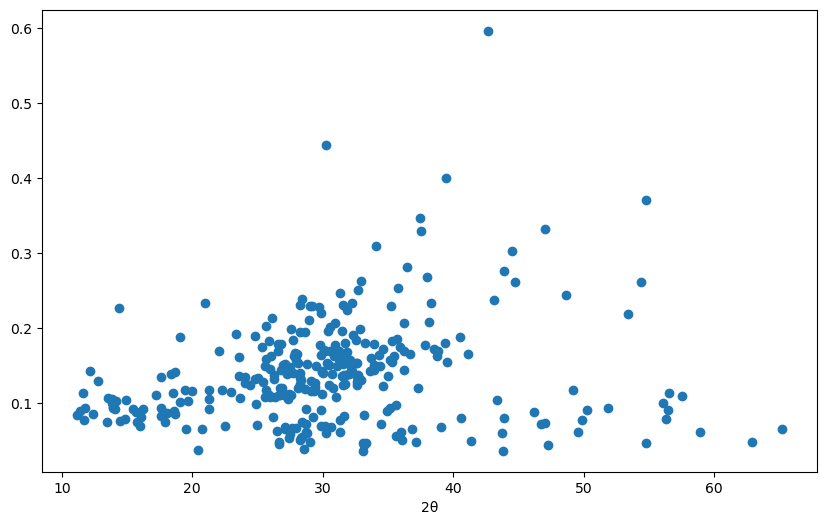

In [245]:
#plot fwhm and peak_two_theta
plt.figure(figsize=(10, 6))
plt.scatter(cated_peak_two_theta, cated_fwhm)
plt.xlabel('2θ')

/tmp/ipykernel_649924/4014654158.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)


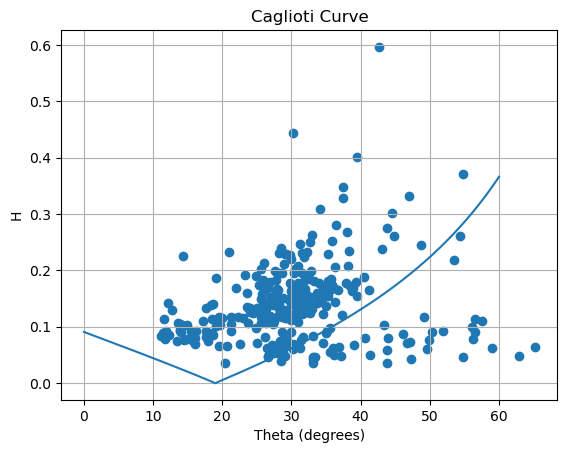

In [273]:
import numpy as np
import matplotlib.pyplot as plt

def caglioti_curve(theta, U, V, W):
    return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)

def fit_caglioti_parameters(two_theta, fwhm):
    params, _ = curve_fit(caglioti_curve, two_theta, fwhm)
    return params

#fit to the cated data
caglioti_params = fit_caglioti_parameters(cated_peak_two_theta, cated_fwhm)

# Define Caglioti parameters
U = caglioti_params[0]
V = caglioti_params[1]
W = caglioti_params[2]

# Generate theta values (in radians)
theta = np.linspace(0, np.pi/3, 1000)  # From 0 to 90 degrees

# Calculate the broadening
broadening = caglioti_curve(theta, U, V, W)

# Plotting
plt.plot(np.degrees(theta), broadening)
plt.scatter(cated_peak_two_theta, cated_fwhm)
plt.xlabel('Theta (degrees)')
plt.ylabel('H')
plt.title('Caglioti Curve')
plt.grid(True)
plt.show()


/tmp/ipykernel_649924/2640642815.py:6: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)


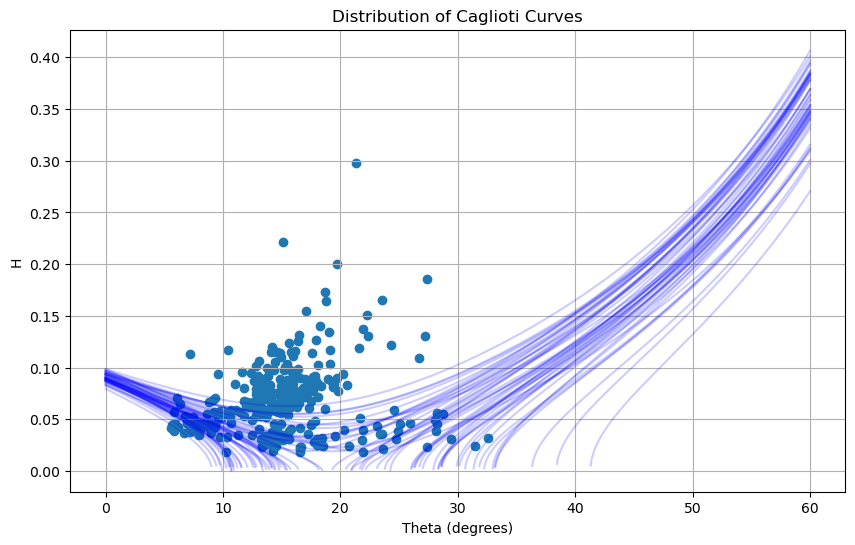

In [257]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def caglioti_curve(theta, U, V, W):
    return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)

def sample_caglioti_parameters(U, V, W, num_samples=100, scale=0.1):
    sampled_params = []
    for _ in range(num_samples):
        U_sampled = np.random.normal(U, np.abs(scale * U))
        V_sampled = np.random.normal(V, np.abs(scale * V))
        W_sampled = np.random.normal(W, np.abs(scale * W))
        sampled_params.append((U_sampled, V_sampled, W_sampled))
    return sampled_params

# Example original Caglioti parameters
U = caglioti_params[0]
V = caglioti_params[1]
W = caglioti_params[2]

# Generate a distribution of curves
num_curves = 50  # Number of curves to generate
sampled_params = sample_caglioti_parameters(U, V, W, num_curves)
a
# Generate theta values (in radians)
theta = np.linspace(0, np.pi/3, 1000)  # From 0 to 60 degrees

# Plotting
plt.figure(figsize=(10, 6))
for params in sampled_params:
    broadening = caglioti_curve(theta, *params)
    plt.plot(np.degrees(theta), broadening, color='blue', alpha=0.2)

# Plot your original data
plt.scatter(cated_peak_two_theta / 2, cated_fwhm / 2)

plt.xlabel('Theta (degrees)')
plt.ylabel('H')
plt.title('Distribution of Caglioti Curves')
plt.grid(True)
plt.show()


In [334]:
import numpy as np
from scipy.stats import norm

def caglioti_curve(theta, U, V, W):
    return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)

def likelihood(params, theta, fwhm):
    U, V, W = params
    predicted_fwhm = caglioti_curve(theta, U, V, W)
    #calculate the mse between the predicted and actual fwhm
    mse = np.mean((predicted_fwhm - fwhm)**2)
    # print(mse)
    return 1 / (mse)

def mcmc_caglioti(theta, fwhm, initial_params, n_iterations, sigma=0.01):
    U, V, W = initial_params
    current_params = np.array([U, V, W])
    current_likelihood = likelihood(current_params, theta, fwhm)

    accepted_params = []
    for _ in range(n_iterations):
        new_params = current_params + np.random.normal(0, sigma, 3)
        new_likelihood = likelihood(new_params, theta, fwhm)
        
        if new_likelihood > current_likelihood or np.random.rand() < np.exp((new_likelihood - current_likelihood)):
            accepted_params.append(new_params)
            current_params = new_params
            current_likelihood = new_likelihood

    return np.array(accepted_params)

/tmp/ipykernel_649924/3227782425.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(U * np.tan(theta)**2 + V * np.tan(theta) + W)


Text(0.5, 1.0, 'Distribution of Caglioti Curves')

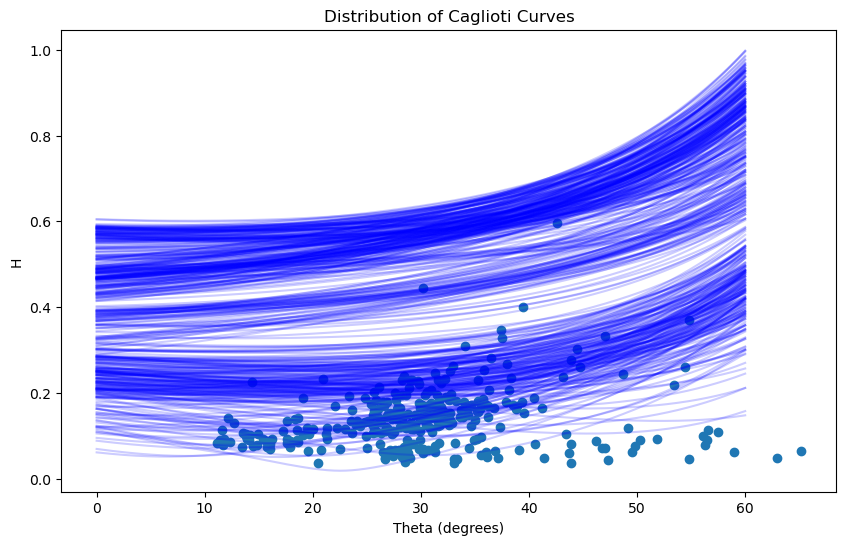

In [335]:

# Example usage
initial_params = [caglioti_params[0], caglioti_params[1], caglioti_params[2]]
n_iterations = 500
accepted_params = mcmc_caglioti(cated_peak_two_theta, cated_fwhm, initial_params, n_iterations)
# print(accepted_params)
#plot the accepted params with the original data
plt.figure(figsize=(10, 6))
for params in accepted_params:
    broadening = caglioti_curve(theta, *params)
    plt.plot(np.degrees(theta), broadening, color='blue', alpha=0.2)

# Plot your original data
plt.scatter(cated_peak_two_theta, cated_fwhm)

plt.xlabel('Theta (degrees)')
plt.ylabel('H')
plt.title('Distribution of Caglioti Curves')

In [179]:
list_of_residuals = []
list_of_non_zero_residuals = []
for i in range(100):
    residuals, non_zero_residuals = plot_xrd_pattern_from_string(i, plot = False)
    list_of_residuals.append(residuals)
    list_of_non_zero_residuals.append(non_zero_residuals)

KeyboardInterrupt: 

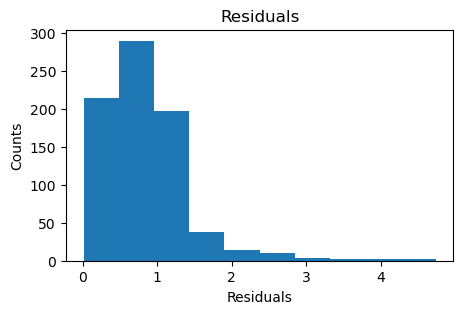

In [81]:
#make a histogram of the residuals
non_zero_residuals = np.concatenate(list_of_non_zero_residuals)
plt.figure(figsize=(5, 3))
plt.hist(non_zero_residuals, bins = 10)
plt.xlabel('Residuals')
plt.ylabel('Counts')
plt.title('Residuals')
plt.show()

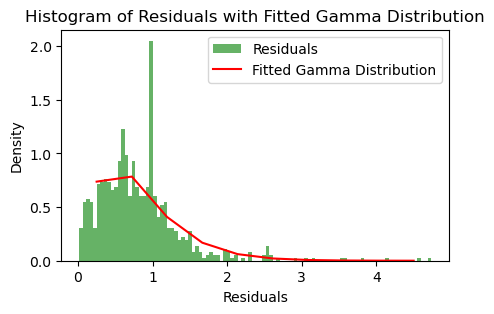

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming non_zero_residuals is already defined
# Generate histogram data
hist_data, bin_edges = np.histogram(non_zero_residuals, bins=10, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Fit a gamma distribution to the data
alpha, loc, scale = stats.gamma.fit(non_zero_residuals)

# Create a range of values to fit the gamma distribution
fitted_data = stats.gamma.pdf(bin_centers, alpha, loc, scale)

# Plot the histogram
plt.figure(figsize=(5, 3))
plt.hist(non_zero_residuals, bins=100, density=True, alpha=0.6, color='g', label='Residuals')

# Plot the fitted distribution
plt.plot(bin_centers, fitted_data, 'r-', label='Fitted Gamma Distribution')

# Add labels and title
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Histogram of Residuals with Fitted Gamma Distribution')
plt.legend()

# Show the plot
plt.show()


In [87]:
# Number of samples to generate
n_samples = 1000

# Generate samples from the fitted gamma distribution


(array([0.15591268, 0.18189813, 0.41576715, 0.49372349, 0.72759251,
        0.83153429, 0.72759251, 0.59766527, 1.01343242, 0.72759251,
        0.44175259, 0.62365072, 0.70160706, 0.7795634 , 1.09138876,
        0.93547608, 1.01343242, 0.83153429, 0.75357795, 0.72759251,
        0.85751974, 0.64963617, 0.59766527, 0.70160706, 0.64963617,
        0.49372349, 0.54569438, 0.51970893, 0.33781081, 0.46773804,
        0.41576715, 0.23386902, 0.33781081, 0.36379625, 0.46773804,
        0.46773804, 0.41576715, 0.20788357, 0.31182536, 0.36379625,
        0.23386902, 0.28583991, 0.23386902, 0.12992723, 0.20788357,
        0.05197089, 0.12992723, 0.15591268, 0.20788357, 0.07795634,
        0.07795634, 0.02598545, 0.05197089, 0.10394179, 0.07795634,
        0.05197089, 0.07795634, 0.05197089, 0.15591268, 0.02598545,
        0.02598545, 0.02598545, 0.05197089, 0.02598545, 0.05197089,
        0.        , 0.        , 0.        , 0.02598545, 0.        ,
        0.        , 0.02598545, 0.        , 0.  

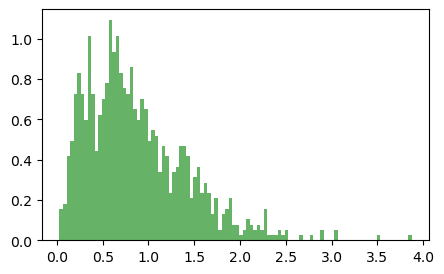

In [89]:
#plot the histogram of the gamma samples
plt.figure(figsize=(5, 3))
plt.hist(gamma_samples, bins=100, density=True, alpha=0.6, color='g', label='Gamma Samples')

In [111]:
import numpy as np
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import matplotlib.pyplot as plt

def modify_xrd(index, alpha, scale): 
    cif_string = test_df['cif'][index]
    xrd_from_test_xrd = test_xrd[test_df['material_id'][index]].numpy()

    # Load the structure from the CIF string
    structure = Structure.from_str(cif_string, fmt="cif")
    # Initialize the XRD calculator with Cu Kα radiation
    xrd_calculator = XRDCalculator(wavelength="CuKa")

    # Get the XRD pattern
    pattern = xrd_calculator.get_pattern(structure)

    myrange = np.arange(5, 90, 0.01)

    # Sum the peaks in the bins defined by the range
    summed_peaks = np.zeros(len(myrange))
    for i in range(len(pattern.x)):
        for j in range(len(myrange)-1):
            if pattern.x[i] > myrange[j] and pattern.x[i] < myrange[j+1]:
                summed_peaks[j] += pattern.y[i]
    summed_peaks = summed_peaks / np.max(summed_peaks)

    n_samples = len(summed_peaks)
    gamma_samples = np.random.gamma(alpha, scale, n_samples)

    # Multiply each peak by a random number from the gamma distribution
    modified_peaks = summed_peaks * gamma_samples

    #renormalize the modified peaks
    modified_peaks = modified_peaks / np.max(modified_peaks)

    # Plot the before and after
    plt.figure(figsize=(10, 6))
    plt.vlines(myrange, 0, summed_peaks, colors='b', label='Original Peaks')
    plt.vlines(myrange, 0, modified_peaks, colors='r', alpha=0.5, label='Modified Peaks')
    plt.xlabel('2θ')
    plt.ylabel('Intensity')
    plt.title('X-ray Diffraction Pattern')
    plt.legend()
    plt.show()


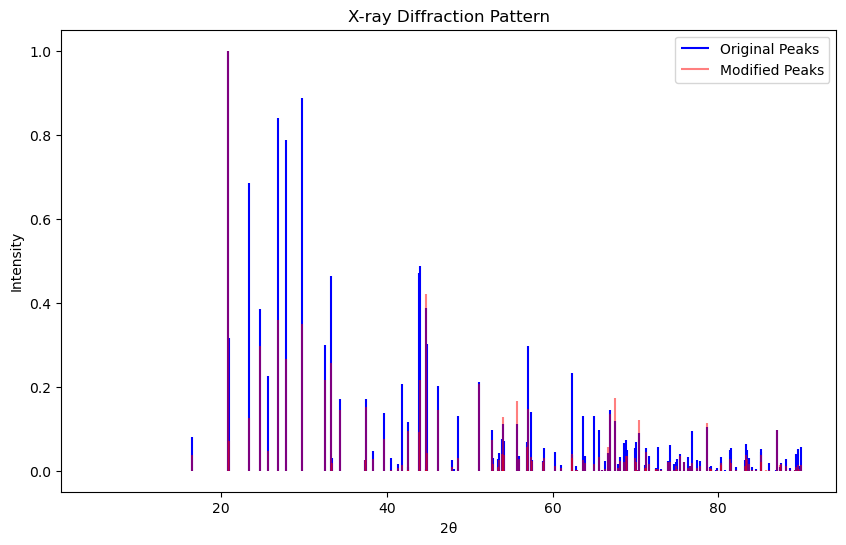

In [112]:
modify_xrd(6, alpha, scale)

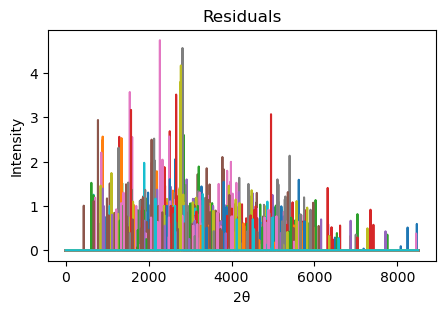

In [82]:
#plot the residuals
plt.figure(figsize=(5, 3))

for i in range(100):
    plt.plot(list_of_residuals[i])
    plt.xlabel('2θ')
    plt.ylabel('Intensity')
    plt.title('Residuals')
plt.show()
